
# 2. Development-set evaluation notebook — ESIM+

This notebook does **standalone evaluation on `dev.csv`**.

It loads one saved bundle file from the training notebook and then:
- rebuilds the model
- evaluates on the development set
- prints the full dev report
- plots confusion matrix / ROC / threshold sweep
- optionally compares against the local scorer baselines if a baseline CSV is provided


In [9]:
!pip -q install torch pandas numpy scikit-learn matplotlib tqdm gensim

In [10]:

import os
import re
import json
import time
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
)



In [11]:
"""
ESIM-style NLI model

Core architecture:
- ESIM: Chen et al. (2017), "Enhanced LSTM for Natural Language Inference"
  https://aclanthology.org/P17-1152/

Extensions:
- learned gated pooling over the composed sequence
- sentence-level interaction features [u, v, |u-v|, u*v]
"""

from __future__ import annotations

import numpy as np
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


def masked_softmax(scores: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Softmax that ignores padded positions."""
    scores = scores.masked_fill(~mask, -1e9)
    return torch.softmax(scores, dim=-1)


class GatedPooling(nn.Module):
    """
    Lightweight learned pooling.

    Plain ESIM uses avg/max pooling after the composition BiLSTM.
    Here we keep avg/max information, but also learn a token importance gate.
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.gate = nn.Linear(input_dim, 1)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x: [batch, seq_len, dim], mask: [batch, seq_len]
        mask_f = mask.unsqueeze(-1).float()

        # Average pooling over valid tokens.
        avg_pool = (x * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1e-6)

        # Max pooling over valid tokens.
        max_pool = x.masked_fill(~mask.unsqueeze(-1), -1e9).max(dim=1).values

        # Learned gated pooling.
        gate_scores = self.gate(x).squeeze(-1)                        # [batch, seq_len]
        gate_scores = gate_scores.masked_fill(~mask, -1e9)
        gate_weights = torch.softmax(gate_scores, dim=1).unsqueeze(-1)
        gated_pool = (x * gate_weights).sum(dim=1)

        return torch.cat([avg_pool, max_pool, gated_pool], dim=-1)


class ESIMPlus(nn.Module):
    """
    ESIM-style NLI encoder/classifier.

    Paper feature map
    -----------------
    Base ESIM features from Chen et al. (2017):
    - BiLSTM encoding
    - soft alignment between premise and hypothesis
    - local inference matching [x, y, x-y, x*y]
    - second BiLSTM composition layer

    Extensions:
    - learned gated pooling
    - sentence-level interaction features [u, v, |u-v|, u*v]

    Local inference vs sentence-level interaction
    ---------------------------------------------
    Local inference is token-level:
        compare each token to its aligned token summary in the other sentence.
    Sentence-level interaction is sequence-level:
        compare the final pooled premise vector u and pooled hypothesis vector v.
    """
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_size: int,
        padding_idx: int = 0,
        embedding_matrix: np.ndarray | None = None,
        dropout: float = 0.3,
        train_embeddings: bool = True,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = train_embeddings

        self.embedding_dropout = nn.Dropout(dropout)

        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        # ESIM local inference vectors have width 8h:
        # [x, y, x-y, x*y] and each x/y is 2h from the BiLSTM.
        self.projection = nn.Sequential(
            nn.Linear(hidden_size * 8, hidden_size),
            nn.ReLU(),
        )

        self.composition = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        composed_dim = hidden_size * 2
        pooled_dim = composed_dim * 3  # avg + max + gated

        self.pooler = GatedPooling(composed_dim)

        # Sentence-level interaction features:
        # u, v, |u-v|, u*v
        classifier_input_dim = pooled_dim * 4
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(classifier_input_dim, hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 1),
        )

    def _run_bilstm(self, x: torch.Tensor, lengths: torch.Tensor, lstm: nn.LSTM):
        lstm.flatten_parameters()
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = lstm(packed)
        output, _ = pad_packed_sequence(packed_output, batch_first=True)
        return output

    def _apply_attention(
        self,
        a: torch.Tensor,
        a_mask: torch.Tensor,
        b: torch.Tensor,
        b_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        # Token-to-token similarity matrix.
        similarity = torch.matmul(a, b.transpose(1, 2))

        b_mask_expanded = b_mask.unsqueeze(1).expand(-1, a.size(1), -1)
        attn_a = masked_softmax(similarity, b_mask_expanded)
        attended_a = torch.matmul(attn_a, b)

        a_mask_expanded = a_mask.unsqueeze(1).expand(-1, b.size(1), -1)
        attn_b = masked_softmax(similarity.transpose(1, 2), a_mask_expanded)
        attended_b = torch.matmul(attn_b, a)

        return attended_a, attended_b

    def forward(
        self,
        premise_ids: torch.Tensor,
        premise_lengths: torch.Tensor,
        hypothesis_ids: torch.Tensor,
        hypothesis_lengths: torch.Tensor,
    ) -> torch.Tensor:
        premise_mask = premise_ids.ne(0)
        hypothesis_mask = hypothesis_ids.ne(0)

        premise_embed = self.embedding_dropout(self.embedding(premise_ids))
        hypothesis_embed = self.embedding_dropout(self.embedding(hypothesis_ids))

        premise_encoded = self._run_bilstm(premise_embed, premise_lengths, self.encoder)
        hypothesis_encoded = self._run_bilstm(hypothesis_embed, hypothesis_lengths, self.encoder)

        premise_aligned, hypothesis_aligned = self._apply_attention(
            premise_encoded, premise_mask, hypothesis_encoded, hypothesis_mask
        )

        # Local inference matching from ESIM.
        premise_enhanced = torch.cat(
            [
                premise_encoded,
                premise_aligned,
                premise_encoded - premise_aligned,
                premise_encoded * premise_aligned,
            ],
            dim=-1,
        )
        hypothesis_enhanced = torch.cat(
            [
                hypothesis_encoded,
                hypothesis_aligned,
                hypothesis_encoded - hypothesis_aligned,
                hypothesis_encoded * hypothesis_aligned,
            ],
            dim=-1,
        )

        premise_projected = self.projection(premise_enhanced)
        hypothesis_projected = self.projection(hypothesis_enhanced)

        premise_composed = self._run_bilstm(premise_projected, premise_lengths, self.composition)
        hypothesis_composed = self._run_bilstm(hypothesis_projected, hypothesis_lengths, self.composition)

        premise_vector = self.pooler(premise_composed, premise_mask)
        hypothesis_vector = self.pooler(hypothesis_composed, hypothesis_mask)

        # Sentence-level interaction features.
        pair_vector = torch.cat(
            [
                premise_vector,
                hypothesis_vector,
                torch.abs(premise_vector - hypothesis_vector),
                premise_vector * hypothesis_vector,
            ],
            dim=-1,
        )

        logits = self.classifier(pair_vector).squeeze(-1)
        return logits


In [12]:

# ---------------------------
# User configuration
# ---------------------------
DEV_PATH = "dev.csv"
MODEL_BUNDLE_PATH = "nli_esim_plus_bundle.pt"

# Optional baseline file from the local scorer bundle.
BASELINE_DEV_CSV = "25_DEV_NLI.csv"

OUTPUT_PREFIX = "nli_esim_plus_dev_eval"


In [13]:

# Shared utility functions used for loading data and reproducing the exact tokenisation.

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

LOWERCASE = True
TOKEN_RE = re.compile(r"\w+|[^\w\s]")

def tokenize(text: str):
    """Use the same lightweight regex tokenizer as training."""
    text = "" if pd.isna(text) else str(text)
    if LOWERCASE:
        text = text.lower()
    return TOKEN_RE.findall(text)

def encode_text(text: str, vocab: dict, max_len: int):
    """Turn one text string into token ids using the saved vocabulary."""
    token_ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokenize(text)[:max_len]]
    if not token_ids:
        token_ids = [vocab["<unk>"]]
    return torch.tensor(token_ids, dtype=torch.long)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [14]:
# Dataset and batch collation.
# The Dataset turns each CSV row into token-id tensors.
# The collate function pads each batch to the longest sequence in the batch and
# returns the true lengths needed by the BiLSTM encoder.

class NLIDataset(Dataset):
    """PyTorch dataset for premise-hypothesis pairs."""
    def __init__(self, dataframe: pd.DataFrame, vocab: dict, max_len: int = 128, with_labels: bool = True):
        self.df = dataframe.reset_index(drop=True).copy()
        self.vocab = vocab
        self.max_len = max_len
        self.with_labels = with_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        premise_ids = encode_text(row["premise"], self.vocab, self.max_len)
        hypothesis_ids = encode_text(row["hypothesis"], self.vocab, self.max_len)

        if self.with_labels:
            label = torch.tensor(float(row["label"]), dtype=torch.float32)
            return premise_ids, hypothesis_ids, label

        return premise_ids, hypothesis_ids

def nli_collate(batch):
    """Pad a batch of variable-length sequences and return true lengths."""
    if len(batch[0]) == 3:
        premises, hypotheses, labels = zip(*batch)
    else:
        premises, hypotheses = zip(*batch)
        labels = None

    premise_lengths = torch.tensor([len(x) for x in premises], dtype=torch.long)
    hypothesis_lengths = torch.tensor([len(x) for x in hypotheses], dtype=torch.long)

    premises = pad_sequence(premises, batch_first=True, padding_value=0)
    hypotheses = pad_sequence(hypotheses, batch_first=True, padding_value=0)

    if labels is None:
        return premises, premise_lengths, hypotheses, hypothesis_lengths

    labels = torch.stack(labels)
    return premises, premise_lengths, hypotheses, hypothesis_lengths, labels



In [15]:
# Training regularisation and evaluation helpers.
# - R-Drop is optional and adds a consistency term between two dropout-enabled
#   forward passes.
# - Metric helpers keep training and evaluation logic consistent.

def bernoulli_symmetric_kl_from_logits(logits_a: torch.Tensor, logits_b: torch.Tensor) -> torch.Tensor:
    """Symmetric KL divergence used by R-Drop for binary logits."""
    p = torch.sigmoid(logits_a).clamp(1e-6, 1 - 1e-6)
    q = torch.sigmoid(logits_b).clamp(1e-6, 1 - 1e-6)

    kl_pq = p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))
    kl_qp = q * torch.log(q / p) + (1 - q) * torch.log((1 - q) / (1 - p))
    return 0.5 * (kl_pq + kl_qp).mean()

def compute_metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """Convert probabilities into hard predictions and compute dev metrics."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1_macro),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics["roc_auc"] = None

    return metrics, y_pred

def evaluate_model(model, dataloader, loss_fn, device, threshold: float = 0.5):
    """Run the model on a dataloader without gradient updates."""
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for premise_ids, premise_lengths, hypothesis_ids, hypothesis_lengths, labels in dataloader:
            premise_ids = premise_ids.to(device)
            premise_lengths = premise_lengths.to(device)
            hypothesis_ids = hypothesis_ids.to(device)
            hypothesis_lengths = hypothesis_lengths.to(device)
            labels = labels.to(device)

            logits = model(premise_ids, premise_lengths, hypothesis_ids, hypothesis_lengths)
            loss = loss_fn(logits, labels)
            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(dataloader))
    metrics, preds = compute_metrics_from_probs(all_labels, all_probs, threshold=threshold)
    metrics["loss"] = float(avg_loss)
    return metrics, np.array(all_labels), np.array(all_probs), np.array(preds)

def find_best_threshold(y_true, y_prob, threshold_min: float = 0.30, threshold_max: float = 0.70, threshold_step: float = 0.02):
    """Search a small threshold range and keep the best macro-F1 value."""
    best_threshold = 0.5
    best_metrics, _ = compute_metrics_from_probs(y_true, y_prob, threshold=0.5)
    best_score = best_metrics["f1_macro"]

    thresholds = np.arange(threshold_min, threshold_max + 1e-9, threshold_step)
    sweep = []
    for threshold in thresholds:
        threshold = float(round(float(threshold), 2))
        metrics, _ = compute_metrics_from_probs(y_true, y_prob, threshold=threshold)
        sweep.append({"threshold": threshold, "f1_macro": metrics["f1_macro"], "accuracy": metrics["accuracy"]})
        if metrics["f1_macro"] > best_score:
            best_score = metrics["f1_macro"]
            best_threshold = threshold
            best_metrics = metrics

    return best_threshold, best_metrics, pd.DataFrame(sweep)

def build_model(vocab_size, embedding_dim, hidden_size, padding_idx, embedding_matrix, dropout, train_embeddings):
    return ESIMPlus(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_size=hidden_size,
        padding_idx=padding_idx,
        embedding_matrix=embedding_matrix,
        dropout=dropout,
        train_embeddings=train_embeddings,
    ).to(device)


def compute_metrics_from_labels(y_true, y_pred):
    """Metric helper for baseline CSVs that already contain hard predictions."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1_macro),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }


Loaded model bundle from: nli_esim_plus_bundle.pt
Best epoch: 9
Best threshold: 0.54
Best dev macro-F1 during training: 0.7364884022741551
{
  "accuracy": 0.7364904988123515,
  "precision_macro": 0.7371048164103444,
  "recall_macro": 0.7371847279276456,
  "f1_macro": 0.7364884022741551,
  "mcc": 0.4742895376059728,
  "roc_auc": 0.8179586957358205,
  "loss": 0.5192759084813999
}
              precision    recall  f1-score   support

         0.0     0.7144    0.7584    0.7357      3258
         1.0     0.7598    0.7159    0.7372      3478

    accuracy                         0.7365      6736
   macro avg     0.7371    0.7372    0.7365      6736
weighted avg     0.7378    0.7365    0.7365      6736

Confusion matrix: [[2471  787]
 [ 988 2490]]
Best threshold found from standalone sweep: 0.54


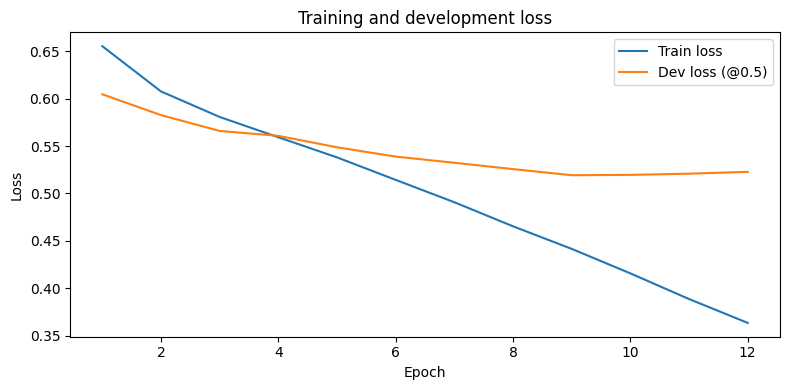

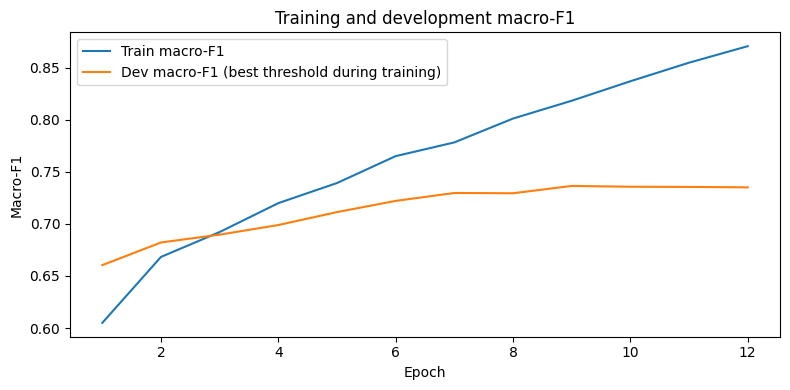

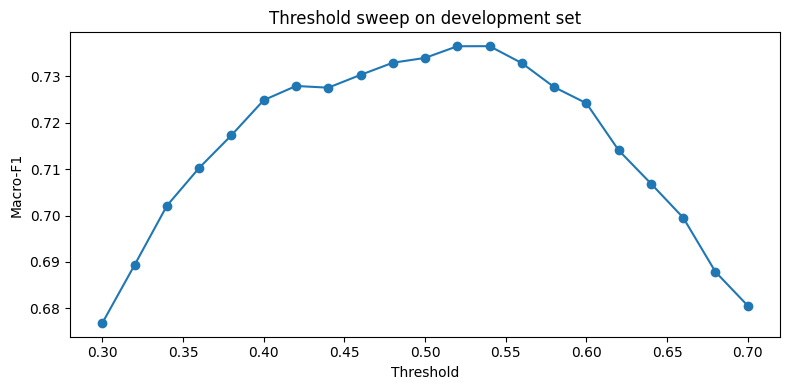

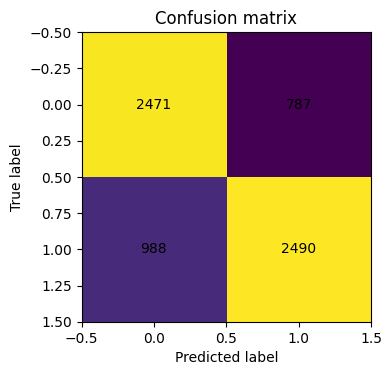

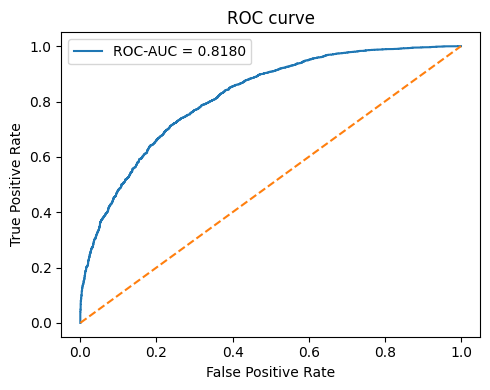

baseline comparison:


,system,accuracy,precision_macro,recall_macro,f1_macro,mcc
3,BERT,0.820220,0.820426,0.819557,0.819821,0.639983
0,ESIM+,0.736490,0.737105,0.737185,0.736488,0.474290
2,LSTM,0.660629,0.660274,0.660286,0.660280,0.320561
1,SVM,0.586253,0.585473,0.584806,0.584584,0.170278


In [16]:

bundle = torch.load(MODEL_BUNDLE_PATH, map_location=device)

vocab = bundle["vocab"]
model_config = bundle["model_config"]
LOWERCASE = bool(model_config["lowercase"])

print("Loaded model bundle from:", MODEL_BUNDLE_PATH)
print("Best epoch:", bundle["best_epoch"])
print("Best threshold:", bundle["best_threshold"])
print("Best dev macro-F1 during training:", bundle["best_dev_metrics"]["f1_macro"])

model = build_model(
    vocab_size=len(vocab),
    embedding_dim=model_config["embedding_dim"],
    hidden_size=model_config["hidden_size"],
    padding_idx=vocab["<pad>"],
    embedding_matrix=None,
    dropout=model_config["dropout"],
    train_embeddings=model_config["train_embeddings"],
)
model.load_state_dict(bundle["model_state_dict"])
model.eval()

dev_df = pd.read_csv(DEV_PATH)
dev_dataset = NLIDataset(dev_df, vocab=vocab, max_len=model_config["max_len"], with_labels=True)
dev_loader = DataLoader(dev_dataset, batch_size=model_config["batch_size"], shuffle=False, collate_fn=nli_collate)

loss_fn = nn.BCEWithLogitsLoss()
best_threshold = float(bundle["best_threshold"])

dev_metrics, dev_labels, dev_probs, dev_preds = evaluate_model(model, dev_loader, loss_fn, device, threshold=best_threshold)

print(json.dumps(dev_metrics, indent=2))
print(classification_report(dev_labels, dev_preds, digits=4))
print("Confusion matrix:", confusion_matrix(dev_labels, dev_preds))

pd.DataFrame({
    "gold_label": dev_labels.astype(int),
    "probability": dev_probs,
    "prediction": dev_preds.astype(int),
}).to_csv(f"{OUTPUT_PREFIX}_predictions.csv", index=False)

threshold, threshold_metrics, threshold_sweep = find_best_threshold(dev_labels, dev_probs)
print(f"Best threshold found from standalone sweep: {threshold}")

history = bundle.get("training_history", [])
if history:
    epochs = [item["epoch"] for item in history]
    train_loss = [item["train"]["loss"] for item in history]
    dev_loss = [item["dev_threshold_0.5"]["loss"] for item in history]
    train_f1 = [item["train"]["f1_macro"] for item in history]
    dev_f1_best = [item["dev_best_threshold"]["f1_macro"] for item in history]

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, dev_loss, label="Dev loss (@0.5)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and development loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_f1, label="Train macro-F1")
    plt.plot(epochs, dev_f1_best, label="Dev macro-F1 (best threshold during training)")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Training and development macro-F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_sweep["threshold"], threshold_sweep["f1_macro"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Macro-F1")
plt.title("Threshold sweep on development set")
plt.tight_layout()
plt.show()

cm = confusion_matrix(dev_labels, dev_preds)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

if dev_metrics["roc_auc"] is not None:
    fpr, tpr, _ = roc_curve(dev_labels, dev_probs)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {dev_metrics['roc_auc']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

if BASELINE_DEV_CSV and os.path.exists(BASELINE_DEV_CSV):
    baseline_df = pd.read_csv(BASELINE_DEV_CSV)
    ref_col = "reference"
    if ref_col not in baseline_df.columns:
        raise ValueError("Baseline CSV must contain a 'reference' column.")

    comparison_rows = []
    comparison_rows.append({"system": "ESIM+", **compute_metrics_from_labels(dev_labels, dev_preds)})
    for col in baseline_df.columns:
        if col in {"Unnamed: 0", ref_col}:
            continue
        comparison_rows.append({"system": col, **compute_metrics_from_labels(baseline_df[ref_col], baseline_df[col])})

    comparison_df = pd.DataFrame(comparison_rows).sort_values(["f1_macro", "accuracy"], ascending=False)
    print("baseline comparison:")
    display(comparison_df)
    comparison_df.to_csv(f"{OUTPUT_PREFIX}_baseline_comparison.csv", index=False)
else:
    print("Baseline comparison skipped. Set BASELINE_DEV_CSV if you want to compare against the local scorer baselines.")
